# 0. Imports & Configs

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/final-project/+ ghost"

In [2]:
# All imports
import torch
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import os
import timm
import time
import json
import gc

import os, sys
# nếu notebook đang chạy trong folder con, thêm parent folder:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from ghost_module import GhostModule

from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Check CUDA availability
print(f"CUDA is available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")
print(f"Current device: {torch.cuda.current_device()}, Device name: {torch.cuda.get_device_name(0)}")
print(f"Device capability: {torch.cuda.get_device_capability(0)}")
print(f"Device properties: {torch.cuda.get_device_properties(0)}")

/home/j/Workspace/Research/asd/train/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA is available: True
CUDA version: 13.0
cuDNN version: 92000
Number of CUDA devices: 1
Current device: 0, Device name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Device capability: (8, 6)
Device properties: _CudaDeviceProperties(name='NVIDIA GeForce RTX 3050 6GB Laptop GPU', major=8, minor=6, total_memory=5806MB, multi_processor_count=20, uuid=0ee50e8b-0c9b-a307-d414-d20a723d7ae3, pci_bus_id=1, pci_device_id=0, pci_domain_id=0, L2_cache_size=1MB)


In [3]:
# Configuration: Base folder and paths
BASE_FOLDER = "/home/j/Workspace/Research/asd/train/"
DATASET_PATH = os.path.join(BASE_FOLDER, "mahmoud-dataset/Images")
MODEL_SAVE_PATH = os.path.join(BASE_FOLDER, "ghost/mobilenetv4_small")
BEST_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, "best.pth")
BEST_HP_PATH = os.path.join(MODEL_SAVE_PATH, "best_hp.json")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print(f"Base folder: {BASE_FOLDER}")
print(f"Dataset path: {DATASET_PATH}")
print(f"Model save path: {MODEL_SAVE_PATH}")

Base folder: /home/j/Workspace/Research/asd/train/
Dataset path: /home/j/Workspace/Research/asd/train/mahmoud-dataset/Images
Model save path: /home/j/Workspace/Research/asd/train/ghost/mobilenetv4_small


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 100
pos_weight = torch.tensor([0.67], device=device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
patience = 10
lr = 1e-5
weight_decay = 1e-4
max_norm = 0.1

In [5]:
def update_training_phase(model, optimizer, epoch):
    """
    Cấu hình rút ngắn dựa trên phân tích hội tụ thực tế.
    """
    # Phase 1: Warm-up Head (Epoch 0-10)
    if epoch == 0:
        for param in model.backbone.parameters():
            param.requires_grad = False
        new_lr = 5e-5
        for param_group in optimizer.param_groups:
            param_group['lr'] = new_lr
        print(f"\n>>> Phase 1: Warm-up | LR = {new_lr}")

    # Phase 2: Deep Fine-tuning (Epoch 11-35)
    elif epoch == 11:
        for name, param in model.backbone.named_parameters():
            if any(f'blocks.{i}' in name for i in [5, 6]):
                param.requires_grad = True
        new_lr = 2e-5
        for param_group in optimizer.param_groups:
            param_group['lr'] = new_lr
        print(f"\n>>> Phase 2: Deep Fine-tuning | LR = {new_lr}")

    # Phase 3: Final Tweak (Epoch 36-70)
    elif epoch == 36:
        for param in model.backbone.parameters():
            param.requires_grad = True
        new_lr = 5e-6
        for param_group in optimizer.param_groups:
            param_group['lr'] = new_lr
        print(f"\n>>> Phase 3: Final Tweak | LR = {new_lr}")

# 1. Load Data

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Added random horizontal flip
    transforms.RandomRotation(15), # Added random rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Added color jitter
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)
targets = [label for _, label in dataset]

# Split 70/30
train_idx, temp_idx = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets,
    random_state=42,
)

# Split 30 to 20/10
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.385,
    stratify=temp_targets,
    random_state=42,
)

train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler   = torch.utils.data.SubsetRandomSampler(val_idx)
test_sampler  = torch.utils.data.SubsetRandomSampler(test_idx)

batch_size = 32

train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
val_loader   = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)
test_loader  = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)

print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
print(f"Train batches: {len(train_loader)},  Val batches: {len(val_loader)},   Test batches: {len(test_loader)}")

Train samples: 382, Val samples: 101, Test samples: 64
Train batches: 12,  Val batches: 4,   Test batches: 2


In [7]:
def count_classes(indices, dataset):
    labels = [dataset.samples[i][1] for i in indices]
    return Counter(labels)

print("Class mapping:", dataset.class_to_idx)
print("Train class count:", count_classes(train_idx, dataset))
print("Val class count:  ", count_classes(val_idx, dataset))
print("Test class count: ", count_classes(test_idx, dataset))

Class mapping: {'ASD': 0, 'non-ASD': 1}
Train class count: Counter({1: 229, 0: 153})
Val class count:   Counter({1: 61, 0: 40})
Test class count:  Counter({1: 38, 0: 26})


# 2. Augment Data

In [8]:
def augment_pre_fmmix1(images, labels):
    B = images.size(0)
    flip_mask = torch.rand(B, device=images.device) < 0.5
    for i in range(B):
        if flip_mask[i]:
            images[i] = torch.flip(images[i], dims=[2])
    brightness_delta = torch.empty(B, 1, 1, 1, device=images.device).uniform_(-0.1, 0.1)
    images = images + brightness_delta
    mean = images.mean(dim=(2, 3), keepdim=True)
    contrast_factor = torch.empty(B, 1, 1, 1, device=images.device).uniform_(0.9, 1.1)
    images = (images - mean) * contrast_factor + mean
    images = torch.clamp(images, 0.0, 1.0)
    return images, labels

class Args:
    def __init__(self, alpha=0.05, mask_area_mode=1):
        self.alpha = alpha
        self.mask_area_mode = mask_area_mode

def fmmix1(args, x, target):
    B, C, H, W = x.shape
    shuffle_idx = torch.randperm(B)
    x_shuffle = x[shuffle_idx]
    max_val_indices = torch.argmax(x_shuffle.view(B, C, -1), dim=2)
    max_indices_unraveled = torch.stack((max_val_indices // W, max_val_indices % W), dim=-1)

    lambdas = torch.sqrt(args.alpha * torch.rand(B, 1, 1, 1, device=x.device))
    Wb = (lambdas * W).squeeze(-1)
    Hb = (lambdas * H).squeeze(-1)

    x_range = torch.arange(W, device=x.device)[None, :].expand(B, C, H, W)
    y_range = torch.arange(H, device=x.device)[:, None].expand(B, C, H, W)
    x_min = torch.clamp(max_indices_unraveled[..., 1][..., None, None] - Wb[..., None] // 2, 0, W)
    y_min = torch.clamp(max_indices_unraveled[..., 0][..., None, None] - Hb[..., None] // 2, 0, H)
    x_max = torch.clamp(x_min + Wb[..., None], 0, W)
    y_max = torch.clamp(y_min + Hb[..., None], 0, H)
    masks = (x_range >= x_min) & (x_range < x_max) & (y_range >= y_min) & (y_range < y_max)
    x = x*~masks + x_shuffle*masks

    target_shuffled = target[shuffle_idx]
    p_src = torch.sum(masks, dim=[1,2,3])/(C*W*H)
    p_tar = 1 - p_src
    return x, [2, [p_tar, p_src], [target, target_shuffled]]

In [9]:
args = Args(alpha=0.05)

# Phương án 1: Thay 1x1 Pointwise Conv bằng GhostModule

Thay thế các lớp Conv 1x1 (pointwise convolution) trong head bằng GhostModule để giảm FLOPs và parameters.

## Build Model - Phương án 1

In [10]:
class ModelPA1(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("mobilenetv4_conv_small.e2400_r224_in1k", pretrained=True, num_classes=0, global_pool="")
        self.gap = torch.nn.AdaptiveAvgPool2d(1)

        # Thay Conv 1x1 bằng GhostModule
        in_features = self.backbone.num_features
        mid_features = in_features // 2
        self.ghost_head = torch.nn.Sequential(
            GhostModule(in_features, mid_features, kernel_size=3, ratio=2), # Changed kernel_size to 3
            torch.nn.ReLU(inplace=True),
            torch.nn.Linear(mid_features, 1)
        )

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.gap(x).flatten(1)
        x = x.unsqueeze(-1).unsqueeze(-1)
        x = self.ghost_head[0](x)
        x = x.flatten(1)
        x = self.ghost_head[1](x)
        x = self.ghost_head[2](x)
        return x

model_pa1 = ModelPA1().to(device)
print(f"PA1 Model. Features: {model_pa1.backbone.num_features}")

PA1 Model. Features: 960


## Train Model - Phương án 1

In [11]:
optimizer_pa1 = torch.optim.Adam(model_pa1.parameters(), lr=lr, weight_decay=weight_decay)
scheduler_pa1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pa1, T_max=num_epochs, eta_min=1e-6)

# Prepare FMMIX args
args_fmmix = Args(alpha=0.05)

best_val_loss_pa1 = float('inf')
patience_counter_pa1 = 0
train_losses_pa1, val_losses_pa1 = [], []
train_accs_pa1, val_accs_pa1 = [], []

for epoch in range(num_epochs):
    update_training_phase(model_pa1, optimizer_pa1, epoch)
    start_time = time.time()
    model_pa1.train()
    train_loss, train_correct, train_total = 0.0, 0.0, 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()

        # FMMIX PASS
        optimizer_pa1.zero_grad()
        images_fm, labels_fm = augment_pre_fmmix1(images.clone(), labels.clone())
        images_fm, computation = fmmix1(args_fmmix, images_fm, labels_fm)

        _, (p_tar, p_src), (y, y_shuf) = computation
        outputs = model_pa1(images_fm).squeeze(1)

        loss_tar = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y, reduction="none")
        loss_src = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y_shuf, reduction="none")
        loss = (p_tar * loss_tar + p_src * loss_src).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pa1.parameters(), max_norm)
        optimizer_pa1.step()

        with torch.no_grad():
            preds = (outputs > 0).int()
            acc_batch = (p_tar * (preds == y.int()).float() + p_src * (preds == y_shuf.int()).float()).sum().item()
            train_correct += acc_batch
            train_loss += loss.item()
            train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)
    train_accs_pa1.append(train_acc)
    train_losses_pa1.append(train_loss)

    model_pa1.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model_pa1(images).squeeze(1)
            val_loss += criterion(outputs, labels).item()
            val_correct += ((torch.sigmoid(outputs) > 0.5).int() == labels.int()).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)
    val_accs_pa1.append(val_acc)
    val_losses_pa1.append(val_loss)

    print(f"[PA1] Epoch {epoch+1}/{num_epochs} | Train: Loss={train_loss:.4f} Acc={train_acc:.4f} | Val: Loss={val_loss:.4f} Acc={val_acc:.4f} | Time={time.time()-start_time:.1f}s")

    scheduler_pa1.step()

    if val_loss < best_val_loss_pa1:
        best_val_loss_pa1 = val_loss
        torch.save(model_pa1.state_dict(), os.path.join(MODEL_SAVE_PATH, 'best_pa1.pth'))
        patience_counter_pa1 = 0
        print(f"  ✓ PA1 best model saved")
    else:
        patience_counter_pa1 += 1
        if patience_counter_pa1 >= patience:
            print(f"PA1 early stopping at epoch {epoch+1}")
            break


>>> Phase 1: Warm-up | LR = 5e-05
[PA1] Epoch 1/100 | Train: Loss=0.6993 Acc=0.5212 | Val: Loss=0.5550 Acc=0.6040 | Time=4.3s
  ✓ PA1 best model saved
[PA1] Epoch 2/100 | Train: Loss=0.6530 Acc=0.6216 | Val: Loss=0.5661 Acc=0.6040 | Time=3.9s
[PA1] Epoch 3/100 | Train: Loss=0.6340 Acc=0.6410 | Val: Loss=0.5824 Acc=0.6040 | Time=3.9s
[PA1] Epoch 4/100 | Train: Loss=0.6239 Acc=0.6855 | Val: Loss=0.5338 Acc=0.6040 | Time=3.1s
  ✓ PA1 best model saved
[PA1] Epoch 5/100 | Train: Loss=0.6100 Acc=0.6640 | Val: Loss=0.5232 Acc=0.6436 | Time=2.7s
  ✓ PA1 best model saved
[PA1] Epoch 6/100 | Train: Loss=0.6183 Acc=0.6439 | Val: Loss=0.5508 Acc=0.5941 | Time=3.9s
[PA1] Epoch 7/100 | Train: Loss=0.6062 Acc=0.6673 | Val: Loss=0.4605 Acc=0.6931 | Time=2.8s
  ✓ PA1 best model saved
[PA1] Epoch 8/100 | Train: Loss=0.6177 Acc=0.6479 | Val: Loss=0.4860 Acc=0.7327 | Time=2.7s
[PA1] Epoch 9/100 | Train: Loss=0.5981 Acc=0.6905 | Val: Loss=0.5075 Acc=0.7030 | Time=2.5s
[PA1] Epoch 10/100 | Train: Loss=0.58

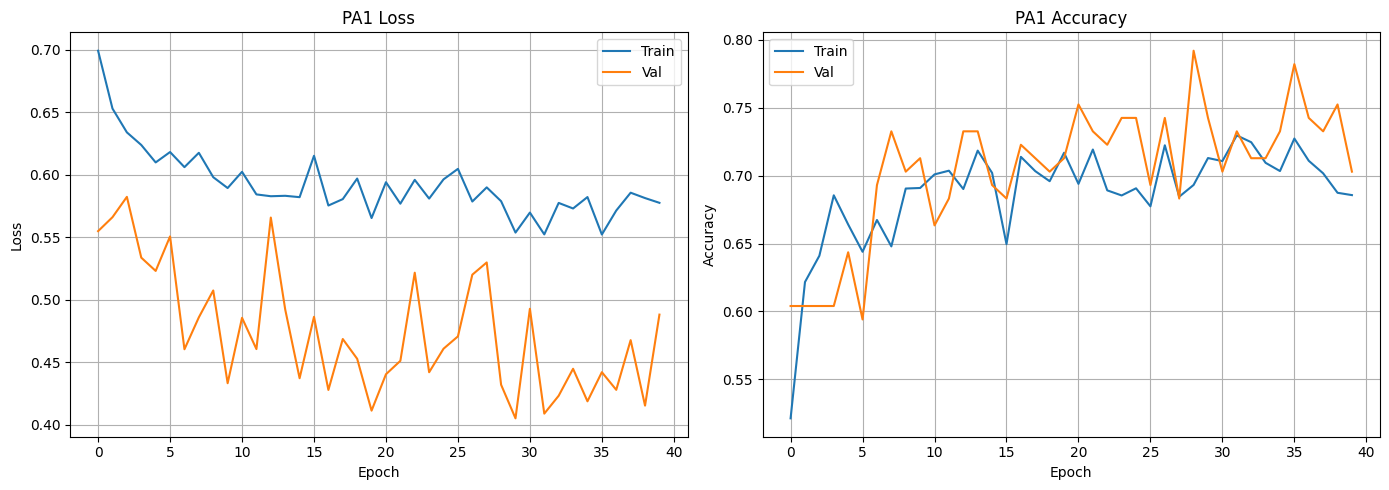

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses_pa1, label='Train'); ax1.plot(val_losses_pa1, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('PA1 Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(train_accs_pa1, label='Train'); ax2.plot(val_accs_pa1, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('PA1 Accuracy'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

## Evaluate Model - Phương án 1

[PA1] Test Accuracy:  0.7812
[PA1] Test Precision: 0.7812
[PA1] Test Recall:    0.7812

              precision    recall  f1-score   support

         ASD       0.73      0.73      0.73        26
     non-ASD       0.82      0.82      0.82        38

    accuracy                           0.78        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.78      0.78      0.78        64



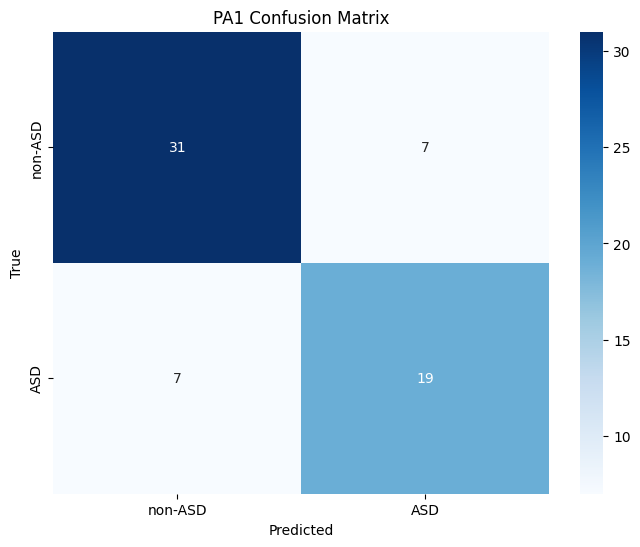

In [13]:
model_pa1.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, 'best_pa1.pth')))
model_pa1.eval()

y_all_pa1, yhat_all_pa1 = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = torch.sigmoid(model_pa1(images.to(device)))
        yhat_all_pa1.extend((outputs > 0.5).int().squeeze(1).cpu().numpy())
        y_all_pa1.extend(labels.numpy())

y_all_pa1, yhat_all_pa1 = np.array(y_all_pa1), np.array(yhat_all_pa1)
accuracy_pa1 = (y_all_pa1 == yhat_all_pa1).mean()
precision_pa1 = precision_score(y_all_pa1, yhat_all_pa1, average='weighted')
recall_pa1 = recall_score(y_all_pa1, yhat_all_pa1, average='weighted')

print(f"[PA1] Test Accuracy:  {accuracy_pa1:.4f}")
print(f"[PA1] Test Precision: {precision_pa1:.4f}")
print(f"[PA1] Test Recall:    {recall_pa1:.4f}")
print("\n" + classification_report(y_all_pa1, yhat_all_pa1, target_names=dataset.classes))

# Confusion Matrix
conf_mat_pa1 = confusion_matrix(1 - y_all_pa1, 1 - yhat_all_pa1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_mat_pa1, annot=True, fmt='g', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('PA1 Confusion Matrix')
ax.xaxis.set_ticklabels(['non-ASD', 'ASD']); ax.yaxis.set_ticklabels(['non-ASD', 'ASD'])
plt.show()

In [14]:
with torch.no_grad():
  torch.cuda.empty_cache()


# Phương án 2: Thay Bottleneck bằng GhostBottleneck

Thay thế toàn bộ bottleneck layers bằng GhostBottleneck từ GhostNet paper.

## Build Model - Phương án 2

In [15]:
class GhostBottleneck(torch.nn.Module):
    def __init__(self, in_ch, out_ch, expansion=2):
        super().__init__()
        mid_ch = in_ch * expansion
        self.ghost1 = GhostModule(in_ch, mid_ch, kernel_size=3, ratio=2) # Changed kernel_size to 3
        self.ghost2 = GhostModule(mid_ch, out_ch, kernel_size=3, ratio=2, relu=False) # Changed kernel_size to 3

    def forward(self, x):
        return self.ghost2(self.ghost1(x))

class ModelPA2(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("mobilenetv4_conv_small.e2400_r224_in1k", pretrained=True, num_classes=0, global_pool="")
        self.gap = torch.nn.AdaptiveAvgPool2d(1)

        # Stack GhostBottlenecks
        in_features = self.backbone.num_features
        self.ghost_bottleneck = torch.nn.Sequential(
            GhostBottleneck(in_features, in_features // 2, expansion=4), # Changed expansion to 4
            torch.nn.ReLU(inplace=True),
            GhostBottleneck(in_features // 2, in_features // 4, expansion=4), # Changed expansion to 4
            torch.nn.ReLU(inplace=True)
        )
        self.head = torch.nn.Linear(in_features // 4, 1)

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.gap(x).flatten(1)
        x = x.unsqueeze(-1).unsqueeze(-1)
        x = self.ghost_bottleneck(x).flatten(1)
        return self.head(x)

model_pa2 = ModelPA2().to(device)
print(f"PA2 Model created. Features: {model_pa2.backbone.num_features}")

PA2 Model created. Features: 960


## Train Model - Phương án 2

In [16]:
optimizer_pa2 = torch.optim.Adam(model_pa2.parameters(), lr=lr, weight_decay=weight_decay)
scheduler_pa2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pa2, T_max=num_epochs, eta_min=1e-6)

best_val_loss_pa2 = float('inf')
patience_counter_pa2 = 0
train_losses_pa2, val_losses_pa2, train_accs_pa2, val_accs_pa2 = [], [], [], []

for epoch in range(num_epochs):
    update_training_phase(model_pa2, optimizer_pa2, epoch)
    start_time = time.time()
    model_pa2.train()
    train_loss, train_correct, train_total = 0.0, 0.0, 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()

        # FMMIX PASS
        optimizer_pa2.zero_grad()
        images_fm, labels_fm = augment_pre_fmmix1(images.clone(), labels.clone())
        images_fm, computation = fmmix1(args_fmmix, images_fm, labels_fm)

        _, (p_tar, p_src), (y, y_shuf) = computation
        outputs = model_pa2(images_fm).squeeze(1)

        loss_tar = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y, reduction="none")
        loss_src = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y_shuf, reduction="none")
        loss = (p_tar * loss_tar + p_src * loss_src).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pa2.parameters(), max_norm)
        optimizer_pa2.step()

        with torch.no_grad():
            preds = (outputs > 0).int()
            acc_batch = (p_tar * (preds == y.int()).float() + p_src * (preds == y_shuf.int()).float()).sum().item()
            train_correct += acc_batch
            train_loss += loss.item()
            train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)
    train_accs_pa2.append(train_acc)
    train_losses_pa2.append(train_loss)

    model_pa2.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model_pa2(images).squeeze(1)
            val_loss += criterion(outputs, labels).item()
            val_correct += ((torch.sigmoid(outputs) > 0.5).int() == labels.int()).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)
    val_accs_pa2.append(val_acc)
    val_losses_pa2.append(val_loss)

    print(f"[PA2] Epoch {epoch+1}/{num_epochs} | Train: Loss={train_loss:.4f} Acc={train_acc:.4f} | Val: Loss={val_loss:.4f} Acc={val_acc:.4f} | Time={time.time()-start_time:.1f}s")

    scheduler_pa2.step()

    if val_loss < best_val_loss_pa2:
        best_val_loss_pa2 = val_loss
        torch.save(model_pa2.state_dict(), os.path.join(MODEL_SAVE_PATH, 'best_pa2.pth'))
        patience_counter_pa2 = 0
        print(f"  ✓ PA2 best model saved")
    else:
        patience_counter_pa2 += 1
        if patience_counter_pa2 >= patience:
            print(f"PA2 early stopping at epoch {epoch+1}")
            break


>>> Phase 1: Warm-up | LR = 5e-05
[PA2] Epoch 1/100 | Train: Loss=0.6580 Acc=0.6135 | Val: Loss=0.5641 Acc=0.3960 | Time=3.1s
  ✓ PA2 best model saved
[PA2] Epoch 2/100 | Train: Loss=0.6240 Acc=0.6548 | Val: Loss=0.5459 Acc=0.3960 | Time=3.0s
  ✓ PA2 best model saved
[PA2] Epoch 3/100 | Train: Loss=0.6147 Acc=0.6516 | Val: Loss=0.5551 Acc=0.6040 | Time=3.0s
[PA2] Epoch 4/100 | Train: Loss=0.5876 Acc=0.7069 | Val: Loss=0.5602 Acc=0.6040 | Time=2.9s
[PA2] Epoch 5/100 | Train: Loss=0.6246 Acc=0.6392 | Val: Loss=0.5594 Acc=0.6040 | Time=3.5s
[PA2] Epoch 6/100 | Train: Loss=0.5692 Acc=0.7241 | Val: Loss=0.5908 Acc=0.6040 | Time=3.0s
[PA2] Epoch 7/100 | Train: Loss=0.5878 Acc=0.7028 | Val: Loss=0.5255 Acc=0.6436 | Time=3.8s
  ✓ PA2 best model saved
[PA2] Epoch 8/100 | Train: Loss=0.5981 Acc=0.6977 | Val: Loss=0.4474 Acc=0.7327 | Time=3.8s
  ✓ PA2 best model saved
[PA2] Epoch 9/100 | Train: Loss=0.5956 Acc=0.6922 | Val: Loss=0.5732 Acc=0.6634 | Time=3.3s
[PA2] Epoch 10/100 | Train: Loss=0.67

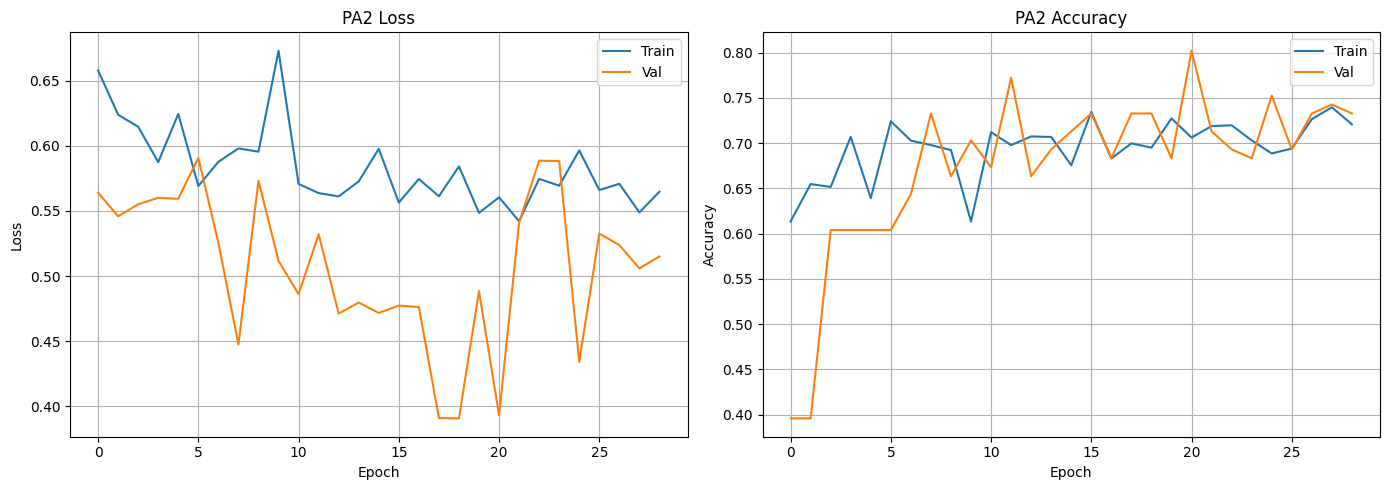

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses_pa2, label='Train'); ax1.plot(val_losses_pa2, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('PA2 Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(train_accs_pa2, label='Train'); ax2.plot(val_accs_pa2, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('PA2 Accuracy'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

In [18]:
with torch.no_grad():
  torch.cuda.empty_cache()


## Evaluate Model - Phương án 2

[PA2] Test Accuracy:  0.8125
[PA2] Test Precision: 0.8115
[PA2] Test Recall:    0.8125

              precision    recall  f1-score   support

         ASD       0.79      0.73      0.76        26
     non-ASD       0.82      0.87      0.85        38

    accuracy                           0.81        64
   macro avg       0.81      0.80      0.80        64
weighted avg       0.81      0.81      0.81        64



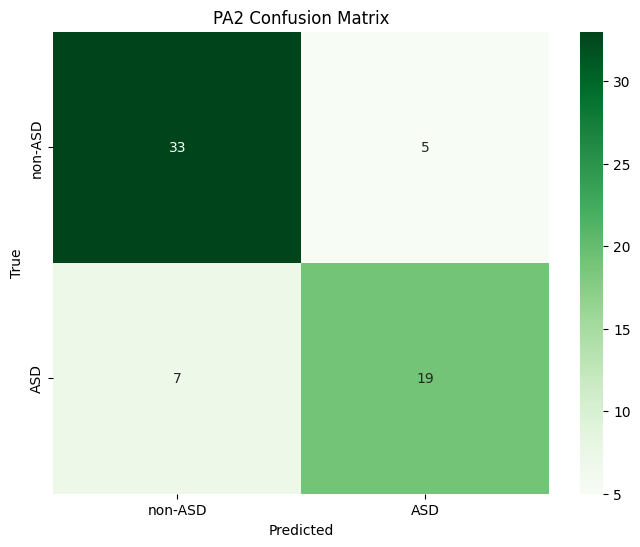

In [19]:
model_pa2.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, 'best_pa2.pth')))
model_pa2.eval()

y_all_pa2, yhat_all_pa2 = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = torch.sigmoid(model_pa2(images.to(device)))
        yhat_all_pa2.extend((outputs > 0.5).int().squeeze(1).cpu().numpy())
        y_all_pa2.extend(labels.numpy())

y_all_pa2, yhat_all_pa2 = np.array(y_all_pa2), np.array(yhat_all_pa2)
accuracy_pa2 = (y_all_pa2 == yhat_all_pa2).mean()
precision_pa2 = precision_score(y_all_pa2, yhat_all_pa2, average='weighted')
recall_pa2 = recall_score(y_all_pa2, yhat_all_pa2, average='weighted')

print(f"[PA2] Test Accuracy:  {accuracy_pa2:.4f}")
print(f"[PA2] Test Precision: {precision_pa2:.4f}")
print(f"[PA2] Test Recall:    {recall_pa2:.4f}")
print("\n" + classification_report(y_all_pa2, yhat_all_pa2, target_names=dataset.classes))

conf_mat_pa2 = confusion_matrix(1 - y_all_pa2, 1 - yhat_all_pa2)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_mat_pa2, annot=True, fmt='g', cmap='Greens', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('PA2 Confusion Matrix')
ax.xaxis.set_ticklabels(['non-ASD', 'ASD']); ax.yaxis.set_ticklabels(['non-ASD', 'ASD'])
plt.show()

# Phương án 3: Chèn GhostModule làm Adapter

Chèn GhostModule làm adapter layer trên đường residual connection hoặc ở head để tinh chỉnh features.

## Build Model - Phương án 3

In [20]:
class GhostAdapter(torch.nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        mid_channels = in_channels // reduction
        self.adapter = torch.nn.Sequential(
            GhostModule(in_channels, mid_channels, kernel_size=3, ratio=2), # Changed kernel_size to 3
            torch.nn.ReLU(inplace=True),
            GhostModule(mid_channels, in_channels, kernel_size=3, ratio=2, relu=False) # Changed kernel_size to 3
        )

    def forward(self, x):
        return x + self.adapter(x)

class ModelPA3(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("mobilenetv4_conv_small.e2400_r224_in1k", pretrained=True, num_classes=0, global_pool="")
        self.gap = torch.nn.AdaptiveAvgPool2d(1)

        in_features = self.backbone.num_features
        self.ghost_adapter = GhostAdapter(in_features, reduction=2) # Changed reduction to 2
        self.head = torch.nn.Linear(in_features, 1)

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.ghost_adapter(x)
        x = self.gap(x).flatten(1)
        return self.head(x)

model_pa3 = ModelPA3().to(device)
print(f"PA3 Model created. Features: {model_pa3.backbone.num_features}")

PA3 Model created. Features: 960


## Train Model - Phương án 3

In [21]:
optimizer_pa3 = torch.optim.Adam(model_pa3.parameters(), lr=lr, weight_decay=weight_decay)
scheduler_pa3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pa3, T_max=num_epochs, eta_min=1e-6)

best_val_loss_pa3 = float('inf')
patience_counter_pa3 = 0
train_losses_pa3, val_losses_pa3, train_accs_pa3, val_accs_pa3 = [], [], [], []

for epoch in range(num_epochs):
    update_training_phase(model_pa3, optimizer_pa3, epoch)
    start_time = time.time()
    model_pa3.train()
    train_loss, train_correct, train_total = 0.0, 0.0, 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()

        # FMMIX PASS
        optimizer_pa3.zero_grad()
        images_fm, labels_fm = augment_pre_fmmix1(images.clone(), labels.clone())
        images_fm, computation = fmmix1(args_fmmix, images_fm, labels_fm)

        _, (p_tar, p_src), (y, y_shuf) = computation
        outputs = model_pa3(images_fm).squeeze(1)

        loss_tar = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y, reduction="none")
        loss_src = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y_shuf, reduction="none")
        loss = (p_tar * loss_tar + p_src * loss_src).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pa3.parameters(), max_norm)
        optimizer_pa3.step()

        with torch.no_grad():
            preds = (outputs > 0).int()
            acc_batch = (p_tar * (preds == y.int()).float() + p_src * (preds == y_shuf.int()).float()).sum().item()
            train_correct += acc_batch
            train_loss += loss.item()
            train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)
    train_accs_pa3.append(train_acc)
    train_losses_pa3.append(train_loss)

    model_pa3.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model_pa3(images).squeeze(1)
            val_loss += criterion(outputs, labels).item()
            val_correct += ((torch.sigmoid(outputs) > 0.5).int() == labels.int()).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)
    val_accs_pa3.append(val_acc)
    val_losses_pa3.append(val_loss)

    print(f"[PA3] Epoch {epoch+1}/{num_epochs} | Train: Loss={train_loss:.4f} Acc={train_acc:.4f} | Val: Loss={val_loss:.4f} Acc={val_acc:.4f} | Time={time.time()-start_time:.1f}s")

    scheduler_pa3.step()

    if val_loss < best_val_loss_pa3:
        best_val_loss_pa3 = val_loss
        torch.save(model_pa3.state_dict(), os.path.join(MODEL_SAVE_PATH, 'best_pa3.pth'))
        patience_counter_pa3 = 0
        print(f"  ✓ PA3 best model saved")
    else:
        patience_counter_pa3 += 1
        if patience_counter_pa3 >= patience:
            print(f"PA3 early stopping at epoch {epoch+1}")
            break


>>> Phase 1: Warm-up | LR = 5e-05
[PA3] Epoch 1/100 | Train: Loss=0.6810 Acc=0.5649 | Val: Loss=0.5535 Acc=0.6040 | Time=2.5s
  ✓ PA3 best model saved
[PA3] Epoch 2/100 | Train: Loss=0.6618 Acc=0.6294 | Val: Loss=0.5494 Acc=0.6238 | Time=2.7s
  ✓ PA3 best model saved
[PA3] Epoch 3/100 | Train: Loss=0.6509 Acc=0.5908 | Val: Loss=0.5279 Acc=0.4851 | Time=3.7s
  ✓ PA3 best model saved
[PA3] Epoch 4/100 | Train: Loss=0.6274 Acc=0.6307 | Val: Loss=0.5480 Acc=0.5644 | Time=3.5s
[PA3] Epoch 5/100 | Train: Loss=0.6023 Acc=0.6749 | Val: Loss=0.4859 Acc=0.6832 | Time=3.1s
  ✓ PA3 best model saved
[PA3] Epoch 6/100 | Train: Loss=0.6059 Acc=0.6679 | Val: Loss=0.5489 Acc=0.6733 | Time=3.3s
[PA3] Epoch 7/100 | Train: Loss=0.6124 Acc=0.6470 | Val: Loss=0.4159 Acc=0.6931 | Time=2.5s
  ✓ PA3 best model saved
[PA3] Epoch 8/100 | Train: Loss=0.5775 Acc=0.7064 | Val: Loss=0.5259 Acc=0.6436 | Time=3.5s
[PA3] Epoch 9/100 | Train: Loss=0.6001 Acc=0.6440 | Val: Loss=0.4015 Acc=0.7525 | Time=2.9s
  ✓ PA3 best

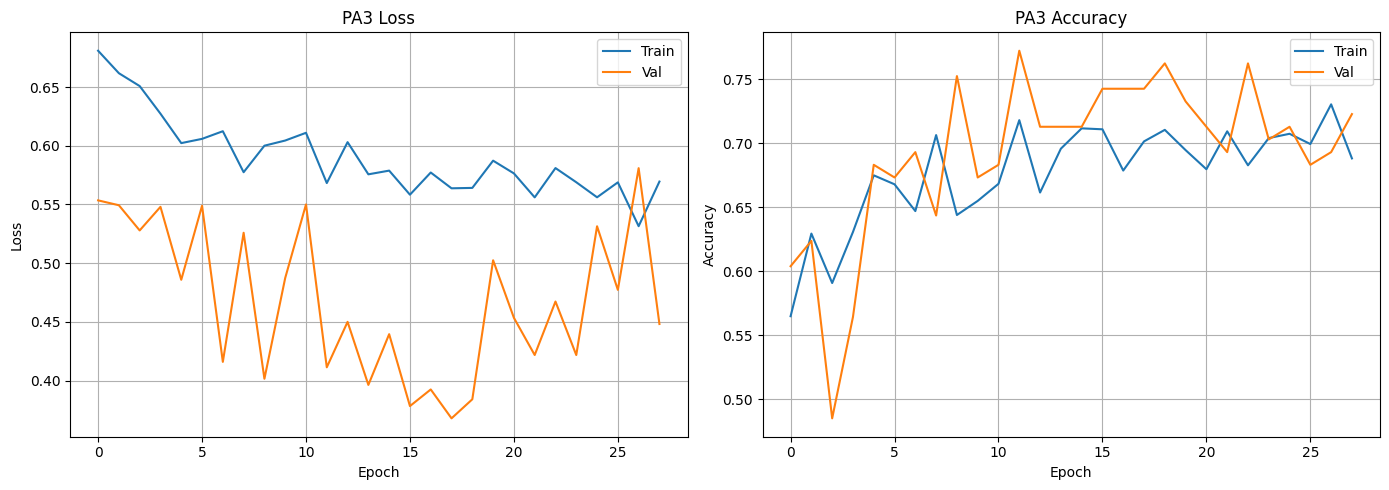

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses_pa3, label='Train'); ax1.plot(val_losses_pa3, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('PA3 Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(train_accs_pa3, label='Train'); ax2.plot(val_accs_pa3, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('PA3 Accuracy'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

## Evaluate Model - Phương án 3

[PA3] Test Accuracy:  0.7812
[PA3] Test Precision: 0.7908
[PA3] Test Recall:    0.7812

              precision    recall  f1-score   support

         ASD       0.70      0.81      0.75        26
     non-ASD       0.85      0.76      0.81        38

    accuracy                           0.78        64
   macro avg       0.78      0.79      0.78        64
weighted avg       0.79      0.78      0.78        64



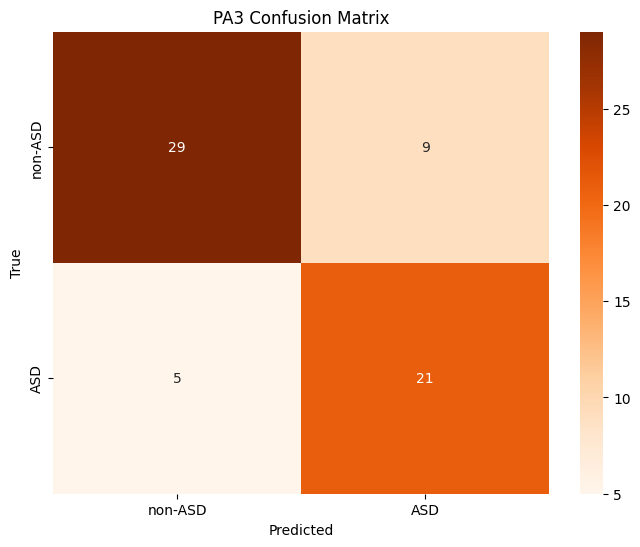

In [23]:
model_pa3.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, 'best_pa3.pth')))
model_pa3.eval()

y_all_pa3, yhat_all_pa3 = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = torch.sigmoid(model_pa3(images.to(device)))
        yhat_all_pa3.extend((outputs > 0.5).int().squeeze(1).cpu().numpy())
        y_all_pa3.extend(labels.numpy())

y_all_pa3, yhat_all_pa3 = np.array(y_all_pa3), np.array(yhat_all_pa3)
accuracy_pa3 = (y_all_pa3 == yhat_all_pa3).mean()
precision_pa3 = precision_score(y_all_pa3, yhat_all_pa3, average='weighted')
recall_pa3 = recall_score(y_all_pa3, yhat_all_pa3, average='weighted')

print(f"[PA3] Test Accuracy:  {accuracy_pa3:.4f}")
print(f"[PA3] Test Precision: {precision_pa3:.4f}")
print(f"[PA3] Test Recall:    {recall_pa3:.4f}")
print("\n" + classification_report(y_all_pa3, yhat_all_pa3, target_names=dataset.classes))

conf_mat_pa3 = confusion_matrix(1 - y_all_pa3, 1 - yhat_all_pa3)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_mat_pa3, annot=True, fmt='g', cmap='Oranges', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('PA3 Confusion Matrix')
ax.xaxis.set_ticklabels(['non-ASD', 'ASD']); ax.yaxis.set_ticklabels(['non-ASD', 'ASD'])
plt.show()